In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

In [4]:
transform_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

In [5]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os


class MultiLabelDataset(Dataset):

    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [29]:
import torch
import torch.nn as nn
import torchvision.models as models

num_classes = 25
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.convnext_small(pretrained=True)
for params in model.parameters():
    params.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

model.classifier[2] = nn.Linear(768, num_classes)
model = model.to(device)

In [16]:
for name, grad in model.classifier.named_parameters():
    print(name, grad.requires_grad)

0.weight True
0.bias True
2.weight True
2.bias True


In [ ]:
NUM_CLASSES = 25

train_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train",
    transform=transform_train,
)

val_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\val_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\val",
    transform=transform_test,
)

test_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\test_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\test",
    transform=transform_test,
)

In [31]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [ ]:
import tqdm, os
from torch.utils.tensorboard import SummaryWriter

os.makedirs("checkpoints", exist_ok=True)

writer = SummaryWriter()

# Loss
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 50

best_val_loss = 1000000
stop_count = 5
early_stop_count = 0
tensorboard_count = 0


for epoch in range(EPOCHS):
    for img, labels in tqdm.tqdm(train_dataloader):
        optimizer.zero_grad()
        preds = model(img.to(device))
        loss = criterion(preds, labels.to(device))
        writer.add_scalar("Loss/Train", loss, tensorboard_count)
        tensorboard_count += 1
        loss.backward()
        optimizer.step()
    # -------  validation  모의고사 시작 -----------------
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, labels in val_dataloader:
            img = img.to(device)
            labels = labels.to(device)
            pred = model(img)
            val_loss += criterion(pred, labels)

    total_val_loss = val_loss / len(val_dataloader)

    # -------- Early Stopping 할것인지 체크

    if total_val_loss < best_val_loss:
        early_stop_count = 0
        best_val_loss = total_val_loss
        torch.save(model.state_dict(), "checkpoints/best_model-확정일자_신청서.pth")
    else:
        early_stop_count += 1

        if early_stop_count >= stop_count:
            break
    print(loss.item())

    print(
        f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {total_val_loss:.4f}, Best Val Loss: {best_val_loss:.4f}, EarlyStopCount: {early_stop_count}"
    )

100%|██████████| 23/23 [00:11<00:00,  2.03it/s]


0.1719990372657776
Epoch 1, Train Loss: 0.1720, Val Loss: 0.1636, Best Val Loss: 0.1636, EarlyStopCount: 0


100%|██████████| 23/23 [00:11<00:00,  1.99it/s]


0.16992445290088654
Epoch 2, Train Loss: 0.1699, Val Loss: 0.1639, Best Val Loss: 0.1636, EarlyStopCount: 1


100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


...

100%|██████████| 23/23 [00:12<00:00,  1.77it/s]


0.16985680162906647
Epoch 11, Train Loss: 0.1699, Val Loss: 0.1635, Best Val Loss: 0.1633, EarlyStopCount: 3


100%|██████████| 23/23 [00:13<00:00,  1.66it/s]


0.1672855168581009
Epoch 12, Train Loss: 0.1673, Val Loss: 0.1634, Best Val Loss: 0.1633, EarlyStopCount: 4


100%|██████████| 23/23 [00:12<00:00,  1.81it/s]


In [22]:
import matplotlib.pyplot as plt


def imshow(img, title):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img.permute(1, 2, 0)
    img = img * std + mean
    plt.title(title)
    plt.imshow(img)
    plt.show()

tensor([[0.9584, 0.9600, 0.9628, 0.9686, 0.9585, 0.9665, 0.9597, 0.9669, 0.9625,
         0.9567, 0.9674, 0.9633, 0.9642, 0.9588, 0.9576, 0.9651, 0.9643, 0.9583,
         0.9623, 0.9577, 0.9573, 0.9584, 0.9595, 0.9542, 0.9624],
        [0.9590, 0.9612, 0.9640, 0.9691, 0.9596, 0.9673, 0.9606, 0.9672, 0.9639,
         0.9585, 0.9687, 0.9646, 0.9657, 0.9604, 0.9590, 0.9663, 0.9655, 0.9596,
         0.9633, 0.9594, 0.9586, 0.9598, 0.9601, 0.9553, 0.9633],
        [0.9584, 0.9595, 0.9634, 0.9680, 0.9580, 0.9664, 0.9593, 0.9663, 0.9625,
         0.9569, 0.9675, 0.9630, 0.9641, 0.9586, 0.9573, 0.9648, 0.9648, 0.9583,
         0.9627, 0.9574, 0.9571, 0.9580, 0.9595, 0.9553, 0.9625],
        [0.9595, 0.9628, 0.9646, 0.9699, 0.9620, 0.9677, 0.9621, 0.9680, 0.9655,
         0.9609, 0.9694, 0.9655, 0.9663, 0.9613, 0.9610, 0.9668, 0.9666, 0.9604,
         0.9641, 0.9603, 0.9601, 0.9612, 0.9611, 0.9557, 0.9639],
        [0.9580, 0.9597, 0.9623, 0.9679, 0.9575, 0.9660, 0.9587, 0.9661, 0.9619,
       

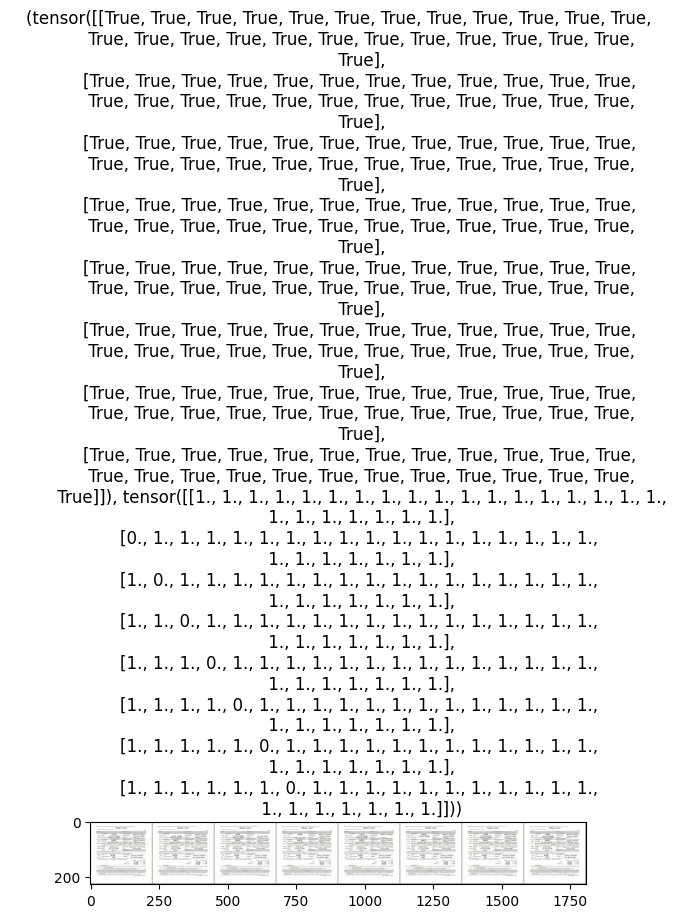

tensor([[0.9582, 0.9602, 0.9620, 0.9680, 0.9577, 0.9660, 0.9582, 0.9664, 0.9617,
         0.9554, 0.9668, 0.9626, 0.9632, 0.9586, 0.9569, 0.9641, 0.9631, 0.9580,
         0.9617, 0.9577, 0.9572, 0.9580, 0.9590, 0.9545, 0.9623],
        [0.9574, 0.9581, 0.9610, 0.9663, 0.9550, 0.9644, 0.9566, 0.9640, 0.9588,
         0.9534, 0.9652, 0.9607, 0.9610, 0.9568, 0.9555, 0.9635, 0.9616, 0.9573,
         0.9604, 0.9567, 0.9543, 0.9560, 0.9580, 0.9533, 0.9617],
        [0.9568, 0.9550, 0.9595, 0.9643, 0.9501, 0.9630, 0.9536, 0.9637, 0.9569,
         0.9473, 0.9628, 0.9579, 0.9594, 0.9542, 0.9514, 0.9603, 0.9597, 0.9560,
         0.9584, 0.9535, 0.9524, 0.9538, 0.9566, 0.9518, 0.9600],
        [0.9579, 0.9587, 0.9618, 0.9673, 0.9558, 0.9648, 0.9578, 0.9653, 0.9603,
         0.9546, 0.9657, 0.9615, 0.9621, 0.9572, 0.9565, 0.9637, 0.9626, 0.9579,
         0.9615, 0.9568, 0.9559, 0.9567, 0.9588, 0.9535, 0.9618],
        [0.9577, 0.9588, 0.9617, 0.9669, 0.9561, 0.9652, 0.9575, 0.9651, 0.9600,
       

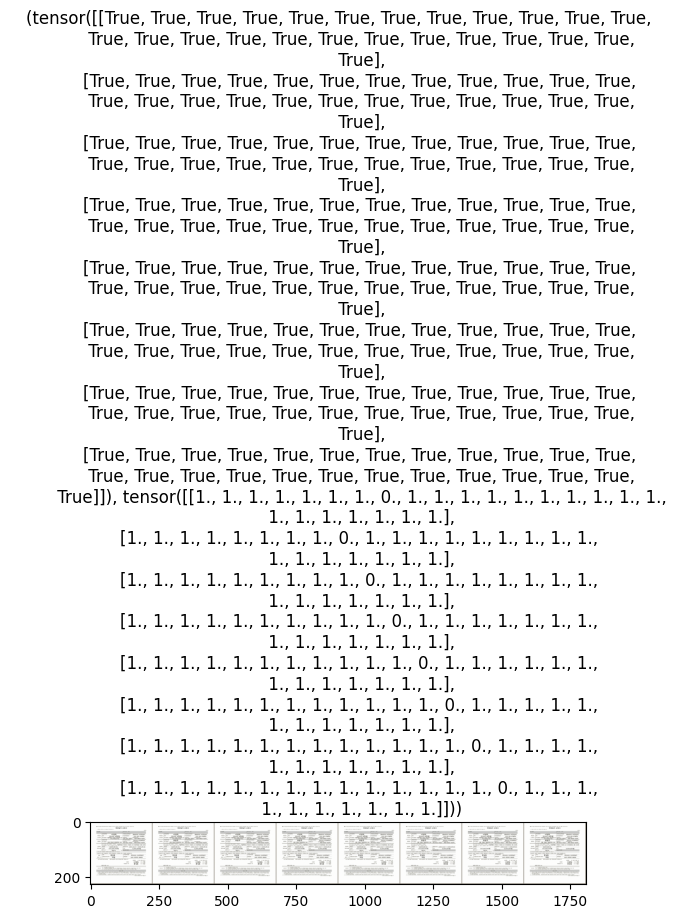

tensor([[0.9582, 0.9591, 0.9619, 0.9675, 0.9563, 0.9649, 0.9581, 0.9657, 0.9609,
         0.9544, 0.9659, 0.9621, 0.9626, 0.9577, 0.9560, 0.9634, 0.9623, 0.9578,
         0.9619, 0.9570, 0.9567, 0.9576, 0.9591, 0.9548, 0.9619],
        [0.9575, 0.9583, 0.9614, 0.9665, 0.9548, 0.9651, 0.9574, 0.9651, 0.9602,
         0.9536, 0.9654, 0.9617, 0.9620, 0.9564, 0.9546, 0.9631, 0.9614, 0.9575,
         0.9607, 0.9563, 0.9554, 0.9568, 0.9585, 0.9539, 0.9612],
        [0.9582, 0.9615, 0.9631, 0.9699, 0.9603, 0.9678, 0.9604, 0.9677, 0.9641,
         0.9586, 0.9686, 0.9648, 0.9656, 0.9603, 0.9597, 0.9665, 0.9646, 0.9585,
         0.9634, 0.9591, 0.9590, 0.9599, 0.9601, 0.9555, 0.9637],
        [0.9577, 0.9619, 0.9627, 0.9704, 0.9612, 0.9685, 0.9603, 0.9675, 0.9648,
         0.9601, 0.9685, 0.9648, 0.9657, 0.9606, 0.9599, 0.9673, 0.9655, 0.9584,
         0.9619, 0.9603, 0.9593, 0.9613, 0.9617, 0.9549, 0.9644],
        [0.9578, 0.9596, 0.9627, 0.9678, 0.9569, 0.9659, 0.9587, 0.9662, 0.9622,
       

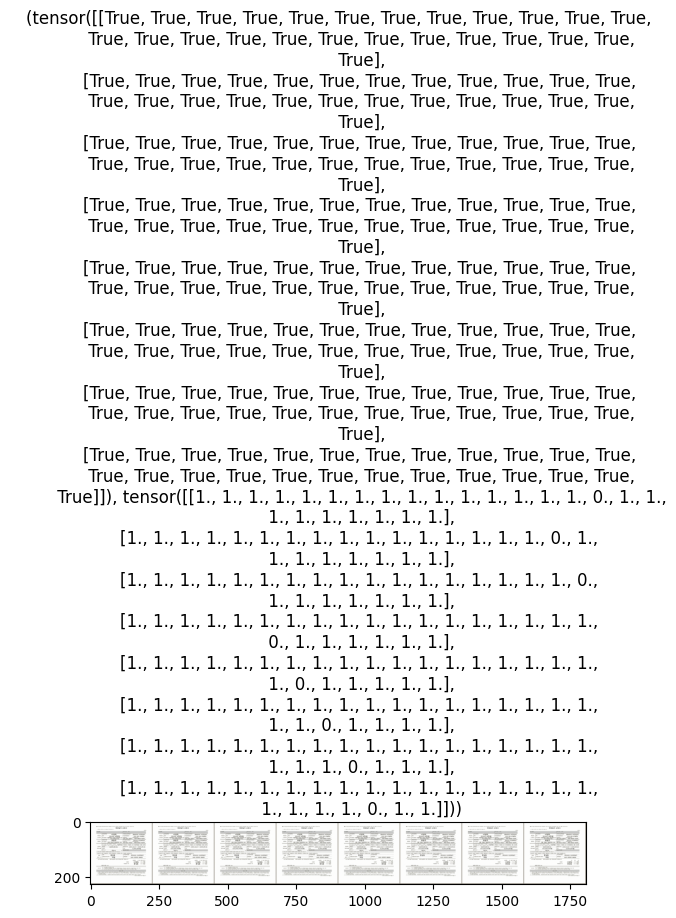

tensor([[0.9591, 0.9614, 0.9636, 0.9693, 0.9602, 0.9673, 0.9613, 0.9681, 0.9647,
         0.9593, 0.9685, 0.9645, 0.9654, 0.9601, 0.9594, 0.9664, 0.9660, 0.9592,
         0.9634, 0.9592, 0.9590, 0.9604, 0.9608, 0.9542, 0.9628],
        [0.9596, 0.9632, 0.9646, 0.9706, 0.9626, 0.9685, 0.9633, 0.9698, 0.9668,
         0.9623, 0.9701, 0.9659, 0.9668, 0.9616, 0.9613, 0.9682, 0.9675, 0.9600,
         0.9639, 0.9610, 0.9609, 0.9621, 0.9623, 0.9552, 0.9641],
        [0.9608, 0.9604, 0.9647, 0.9610, 0.9626, 0.9634, 0.9601, 0.9604, 0.9624,
         0.9619, 0.9611, 0.9598, 0.9626, 0.9605, 0.9617, 0.9606, 0.9600, 0.9601,
         0.9604, 0.9609, 0.9624, 0.9611, 0.9618, 0.9616, 0.9602],
        [0.9604, 0.9600, 0.9643, 0.9605, 0.9620, 0.9631, 0.9594, 0.9598, 0.9618,
         0.9611, 0.9607, 0.9593, 0.9619, 0.9603, 0.9612, 0.9602, 0.9594, 0.9598,
         0.9600, 0.9605, 0.9617, 0.9608, 0.9615, 0.9614, 0.9599],
        [0.9603, 0.9592, 0.9639, 0.9601, 0.9615, 0.9625, 0.9588, 0.9596, 0.9612,
       

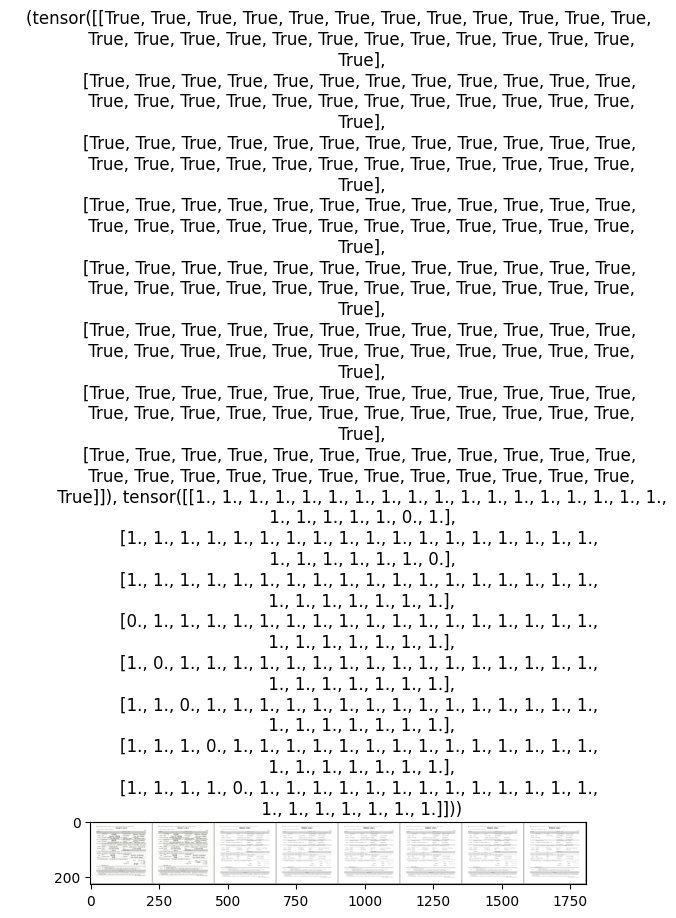

tensor([[0.9607, 0.9608, 0.9649, 0.9616, 0.9628, 0.9635, 0.9602, 0.9605, 0.9626,
         0.9629, 0.9613, 0.9604, 0.9627, 0.9607, 0.9625, 0.9610, 0.9606, 0.9605,
         0.9606, 0.9614, 0.9628, 0.9614, 0.9621, 0.9619, 0.9608],
        [0.9603, 0.9597, 0.9643, 0.9601, 0.9614, 0.9623, 0.9592, 0.9596, 0.9612,
         0.9610, 0.9600, 0.9588, 0.9614, 0.9597, 0.9609, 0.9599, 0.9591, 0.9601,
         0.9595, 0.9605, 0.9617, 0.9605, 0.9615, 0.9613, 0.9597],
        [0.9605, 0.9599, 0.9643, 0.9607, 0.9620, 0.9630, 0.9594, 0.9600, 0.9617,
         0.9611, 0.9605, 0.9592, 0.9618, 0.9600, 0.9612, 0.9600, 0.9593, 0.9598,
         0.9599, 0.9605, 0.9619, 0.9607, 0.9613, 0.9614, 0.9598],
        [0.9605, 0.9596, 0.9643, 0.9604, 0.9620, 0.9627, 0.9596, 0.9598, 0.9615,
         0.9614, 0.9604, 0.9589, 0.9617, 0.9598, 0.9610, 0.9600, 0.9594, 0.9600,
         0.9596, 0.9605, 0.9621, 0.9604, 0.9616, 0.9613, 0.9600],
        [0.9599, 0.9589, 0.9636, 0.9599, 0.9611, 0.9623, 0.9586, 0.9593, 0.9608,
       

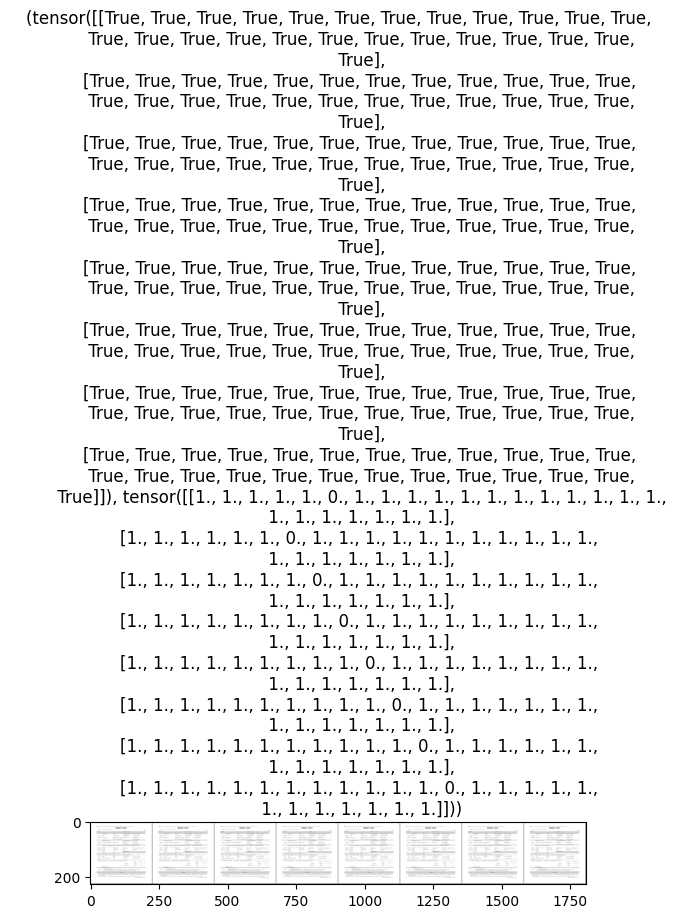

tensor([[0.9601, 0.9597, 0.9640, 0.9601, 0.9614, 0.9626, 0.9588, 0.9593, 0.9613,
         0.9606, 0.9599, 0.9589, 0.9615, 0.9597, 0.9604, 0.9597, 0.9586, 0.9596,
         0.9595, 0.9603, 0.9614, 0.9606, 0.9612, 0.9611, 0.9597],
        [0.9601, 0.9596, 0.9643, 0.9602, 0.9616, 0.9630, 0.9594, 0.9596, 0.9618,
         0.9606, 0.9600, 0.9591, 0.9617, 0.9599, 0.9605, 0.9599, 0.9591, 0.9597,
         0.9595, 0.9604, 0.9616, 0.9605, 0.9614, 0.9612, 0.9595],
        [0.9596, 0.9588, 0.9632, 0.9594, 0.9603, 0.9621, 0.9577, 0.9585, 0.9603,
         0.9591, 0.9589, 0.9579, 0.9602, 0.9588, 0.9592, 0.9585, 0.9575, 0.9588,
         0.9588, 0.9594, 0.9607, 0.9597, 0.9605, 0.9607, 0.9588],
        [0.9603, 0.9599, 0.9641, 0.9599, 0.9618, 0.9631, 0.9593, 0.9597, 0.9617,
         0.9606, 0.9602, 0.9592, 0.9618, 0.9598, 0.9606, 0.9595, 0.9588, 0.9595,
         0.9595, 0.9604, 0.9618, 0.9606, 0.9613, 0.9617, 0.9595],
        [0.9604, 0.9600, 0.9639, 0.9601, 0.9615, 0.9628, 0.9594, 0.9600, 0.9614,
       

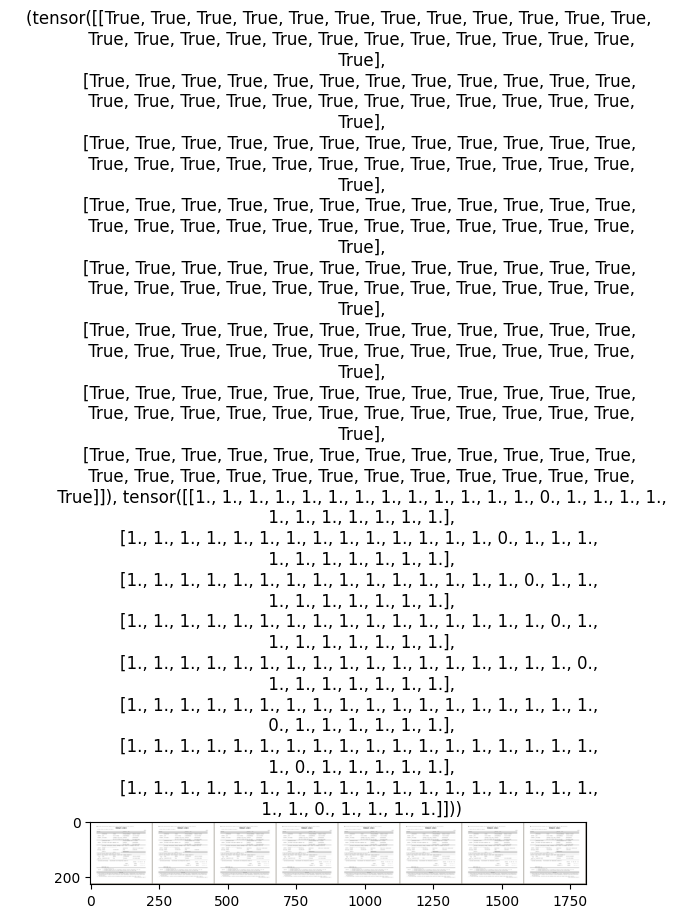

tensor([[0.9603, 0.9601, 0.9644, 0.9604, 0.9617, 0.9631, 0.9595, 0.9596, 0.9620,
         0.9613, 0.9603, 0.9592, 0.9623, 0.9602, 0.9608, 0.9600, 0.9590, 0.9597,
         0.9601, 0.9606, 0.9618, 0.9610, 0.9616, 0.9619, 0.9600],
        [0.9610, 0.9615, 0.9659, 0.9615, 0.9632, 0.9639, 0.9614, 0.9611, 0.9637,
         0.9637, 0.9622, 0.9604, 0.9642, 0.9615, 0.9629, 0.9617, 0.9608, 0.9609,
         0.9606, 0.9620, 0.9634, 0.9623, 0.9626, 0.9623, 0.9613],
        [0.9608, 0.9614, 0.9650, 0.9618, 0.9635, 0.9640, 0.9607, 0.9610, 0.9635,
         0.9630, 0.9615, 0.9605, 0.9631, 0.9608, 0.9625, 0.9616, 0.9606, 0.9609,
         0.9606, 0.9620, 0.9631, 0.9620, 0.9623, 0.9613, 0.9599],
        [0.9602, 0.9604, 0.9641, 0.9608, 0.9623, 0.9634, 0.9595, 0.9600, 0.9621,
         0.9612, 0.9606, 0.9595, 0.9619, 0.9599, 0.9613, 0.9604, 0.9594, 0.9599,
         0.9599, 0.9609, 0.9619, 0.9609, 0.9614, 0.9609, 0.9592]],
       device='cuda:0')


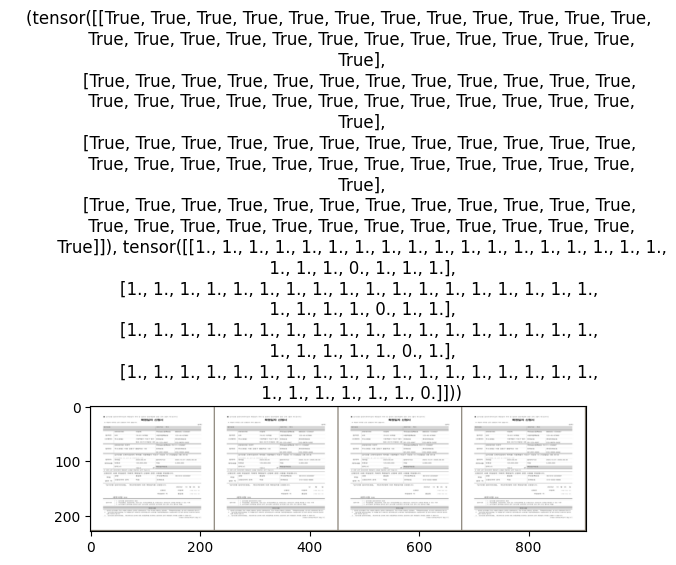

정확도 : 0.9615384615384616


In [ ]:
model.eval()

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        print(probs)
        pred = probs > 0.3  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        img_grid = torchvision.utils.make_grid(img.cpu())

        imshow(img_grid, title=(pred.cpu(), labels.cpu()))

    acc = corrects / total
    print("정확도 :", acc)

In [42]:
from sklearn.metrics import f1_score
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)

        probs = torch.sigmoid(preds)
        pred = (probs > 0.5).int()

        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

f1_micro = f1_score(all_labels, all_preds, average="micro")
f1_macro = f1_score(all_labels, all_preds, average="macro")
f1_weighted = f1_score(all_labels, all_preds, average="weighted")

print("F1 micro :", f1_micro)
print("F1 macro :", f1_macro)
print("F1 weighted :", f1_weighted)

F1 micro : 0.9803921568627451
F1 macro : 0.9803921568627451
F1 weighted : 0.9803921568627451


In [73]:
import torch
import torch.nn as nn
import torchvision.models as models

num_classes = 25
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.convnext_small(pretrained=True)

# classifier 변경
model.classifier[2] = nn.Linear(768, num_classes)

# 모든 layer freeze
for param in model.parameters():
    param.requires_grad = False

# classifier 학습
for param in model.classifier.parameters():
    param.requires_grad = True

# backbone 일부 학습
for param in model.features[-2:].parameters():
    param.requires_grad = True

model = model.to(device)

In [74]:
from torchvision import datasets, models, transforms

transform_train = transforms.Compose(
    [
        transforms.Resize((512, 768)),
        transforms.RandomRotation(2),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)


transform_test = transforms.Compose(
    [
        transforms.Resize((512, 768)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

In [75]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os


class MultiLabelDataset(Dataset):

    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
NUM_CLASSES = 25

train_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train",
    transform=transform_train,
)

val_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\val_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\val",
    transform=transform_test,
)

test_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\test_labels.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\test",
    transform=transform_test,
)

In [77]:
len(train_dataset)

3420

In [78]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train_labels.csv"
)

labels = df.iloc[:, 1:].values

pos_counts = labels.sum(axis=0)
neg_counts = labels.shape[0] - pos_counts

pos_weight = neg_counts / pos_counts

pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

In [ ]:
import tqdm
from torch.utils.tensorboard import SummaryWriter
import os

os.makedirs("checkpoints", exist_ok=True)

writer = SummaryWriter()

# Loss

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 50

best_val_loss = 1000000
stop_count = 5
early_stop_count = 0
tensorboard_count = 0


for epoch in range(EPOCHS):
    for img, labels in tqdm.tqdm(train_dataloader):
        optimizer.zero_grad()
        preds = model(img.to(device))
        loss = criterion(preds, labels.to(device))
        writer.add_scalar("Loss/Train", loss, tensorboard_count)
        tensorboard_count += 1
        loss.backward()
        optimizer.step()
    # -------  validation  모의고사 시작 -----------------
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, labels in val_dataloader:
            img = img.to(device)
            labels = labels.to(device)
            pred = model(img)
            val_loss += criterion(pred, labels)

    total_val_loss = val_loss / len(val_dataloader)

    # -------- Early Stopping 할것인지 체크

    if total_val_loss < best_val_loss:
        early_stop_count = 0
        best_val_loss = total_val_loss
        torch.save(model.state_dict(), "checkpoints/best_model-01doc.pth")
    else:
        early_stop_count += 1

        if early_stop_count >= stop_count:
            break
    print(loss.item())

    print(
        f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {total_val_loss:.4f}, Best Val Loss: {best_val_loss:.4f}, EarlyStopCount: {early_stop_count}"
    )

100%|██████████| 428/428 [07:37<00:00,  1.07s/it]


0.020135173574090004
Epoch 1, Train Loss: 0.0201, Val Loss: 0.0341, Best Val Loss: 0.0341, EarlyStopCount: 0


100%|██████████| 428/428 [07:33<00:00,  1.06s/it]


9.271971794078127e-05
Epoch 2, Train Loss: 0.0001, Val Loss: 0.0299, Best Val Loss: 0.0299, EarlyStopCount: 0


100%|██████████| 428/428 [07:31<00:00,  1.06s/it]


...

100%|██████████| 428/428 [09:05<00:00,  1.27s/it]


0.00341601250693202
Epoch 21, Train Loss: 0.0034, Val Loss: 0.0057, Best Val Loss: 0.0046, EarlyStopCount: 1


100%|██████████| 428/428 [09:01<00:00,  1.27s/it]


0.0025661950930953026
Epoch 22, Train Loss: 0.0026, Val Loss: 0.0050, Best Val Loss: 0.0046, EarlyStopCount: 2


100%|██████████| 428/428 [09:03<00:00,  1.27s/it]


In [ ]:
image = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train\002-06_임차인_전화번호_없음.jpg"
).convert("RGB")


input_tensor_image = transform_test(image).to(device)

model.eval()

with torch.no_grad():

    output = model(input_tensor_image.unsqueeze(0).cuda())

    probs = torch.sigmoid(output)

    print(probs)

    preds = (probs > 0.5).int()

print(preds)

tensor([[0.9998, 0.9997, 0.9999, 1.0000, 0.9999, 0.1317, 0.9992, 0.9766, 0.9996,
         0.9999, 0.3817, 0.9958, 1.0000, 0.9998, 0.9973, 0.9998, 0.9733, 0.9558,
         0.7716, 0.9986, 0.1134, 0.9994, 0.9929, 0.9996, 0.9909]],
       device='cuda:0')
tensor([[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
         1]], device='cuda:0', dtype=torch.int32)


In [84]:
import matplotlib.pyplot as plt


def imshow(img, title):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img.permute(1, 2, 0)
    img = img * std + mean
    plt.title(title)
    plt.imshow(img)
    plt.show()

tensor([[9.9895e-01, 9.9960e-01, 9.9993e-01, 9.9993e-01, 9.9981e-01, 1.7217e-01,
         9.9341e-01, 9.7876e-01, 9.9911e-01, 9.9992e-01, 6.3261e-01, 9.9810e-01,
         1.0000e+00, 9.9906e-01, 9.9890e-01, 9.9911e-01, 9.9334e-01, 8.6768e-01,
         9.5724e-01, 9.9651e-01, 7.3330e-01, 9.9846e-01, 9.9881e-01, 9.9991e-01,
         9.9808e-01],
        [6.5444e-05, 9.9997e-01, 9.9998e-01, 9.9987e-01, 9.9980e-01, 9.9924e-01,
         9.9973e-01, 9.9909e-01, 9.9971e-01, 9.9988e-01, 9.9931e-01, 9.9982e-01,
         9.9980e-01, 9.9944e-01, 9.9965e-01, 9.9953e-01, 9.9981e-01, 9.9955e-01,
         9.9975e-01, 9.9934e-01, 9.9965e-01, 9.9974e-01, 9.9992e-01, 9.9951e-01,
         9.9947e-01],
        [9.9996e-01, 3.7278e-05, 9.9998e-01, 9.9994e-01, 9.9991e-01, 9.9955e-01,
         9.9989e-01, 9.9983e-01, 9.9992e-01, 9.9991e-01, 9.9979e-01, 9.9992e-01,
         9.9995e-01, 9.9980e-01, 9.9987e-01, 9.9984e-01, 9.9973e-01, 9.9980e-01,
         9.9983e-01, 9.9988e-01, 9.9975e-01, 9.9995e-01, 9.9992e-

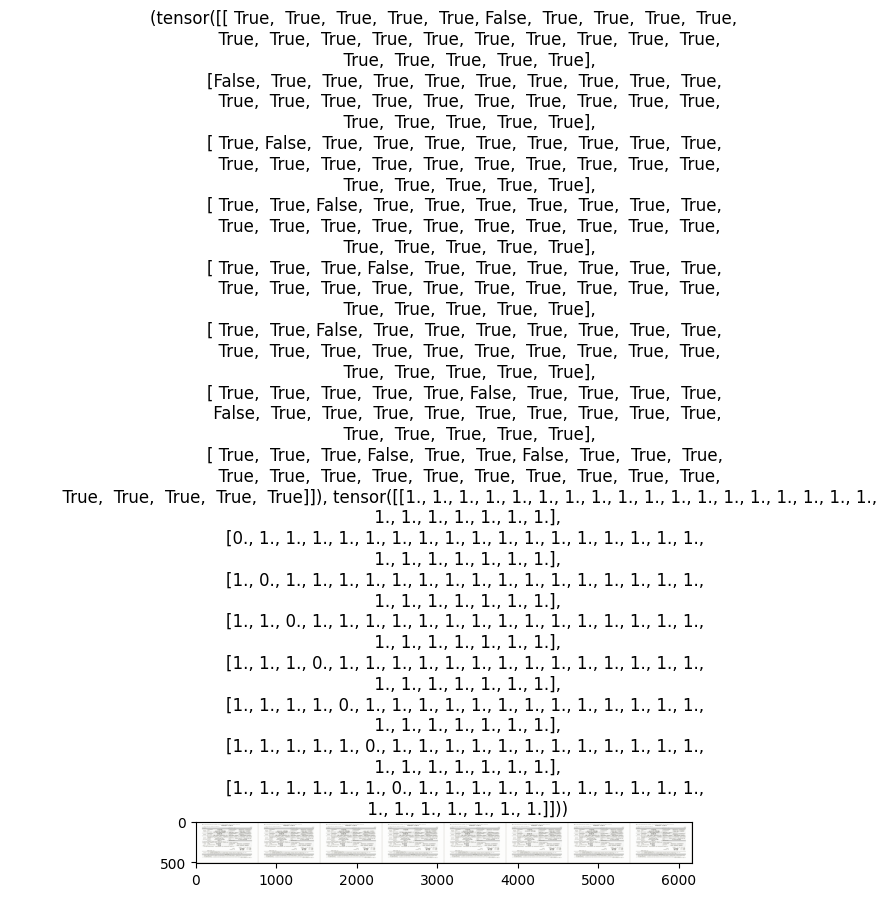

tensor([[9.7350e-01, 9.9940e-01, 9.9140e-01, 9.9959e-01, 9.9529e-01, 7.5108e-01,
         9.9557e-01, 4.6314e-03, 9.9843e-01, 9.9967e-01, 9.2914e-01, 9.9759e-01,
         9.9994e-01, 9.9790e-01, 9.9782e-01, 9.9956e-01, 9.9264e-01, 9.9357e-01,
         9.8366e-01, 9.9847e-01, 7.5245e-01, 9.9704e-01, 9.9743e-01, 9.9968e-01,
         9.9579e-01],
        [9.9985e-01, 9.9993e-01, 9.9946e-01, 9.8253e-01, 9.9527e-01, 9.7898e-01,
         8.6448e-04, 9.9847e-01, 5.8882e-01, 9.9967e-01, 9.9759e-01, 9.9973e-01,
         9.9999e-01, 9.9872e-01, 9.9872e-01, 9.9914e-01, 9.9979e-01, 9.9752e-01,
         9.9704e-01, 9.9934e-01, 9.9807e-01, 9.9390e-01, 9.9917e-01, 9.9938e-01,
         9.9783e-01],
        [9.7750e-01, 9.9844e-01, 9.9980e-01, 9.9960e-01, 9.9901e-01, 7.1787e-01,
         9.9513e-01, 2.6059e-04, 9.9338e-01, 7.9826e-01, 8.7877e-01, 9.9491e-01,
         9.9737e-01, 9.8009e-01, 9.9892e-01, 9.9864e-01, 9.8940e-01, 9.9390e-01,
         9.9914e-01, 9.9861e-01, 9.6836e-01, 9.9500e-01, 9.8776e-

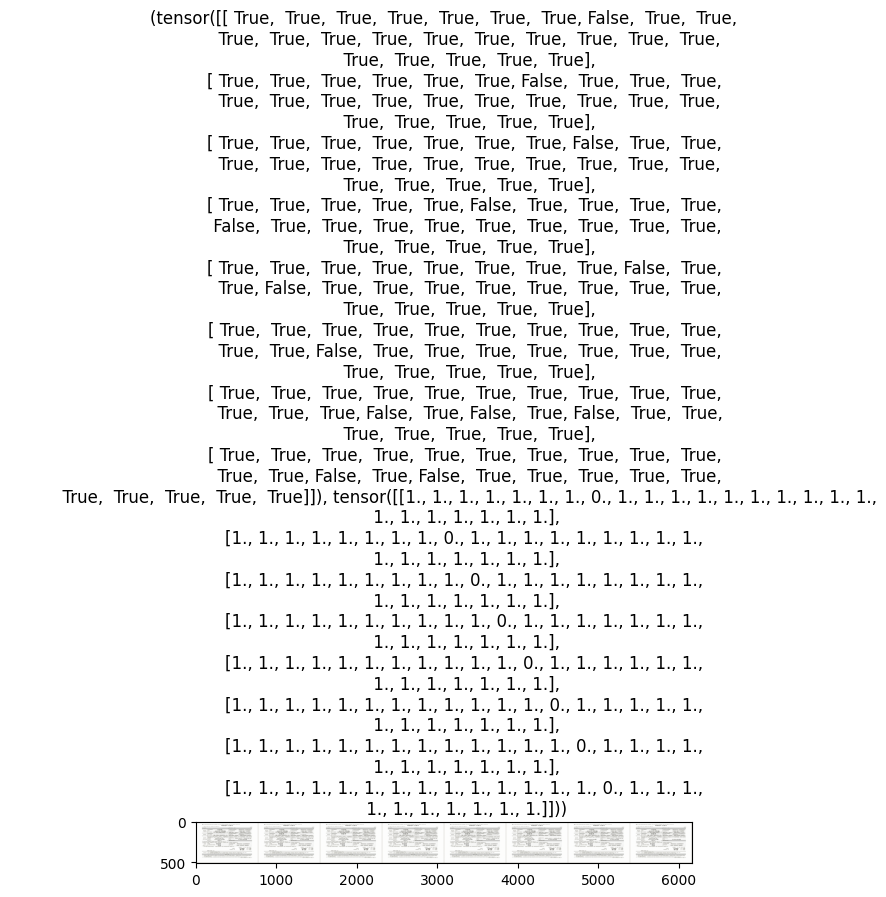

tensor([[0.9994, 0.9998, 0.9991, 0.9990, 0.9998, 0.9848, 0.9961, 0.9899, 0.9988,
         0.9998, 0.9960, 0.9999, 0.9996, 0.0521, 0.9995, 0.0247, 0.9999, 0.6386,
         0.9969, 0.9964, 0.9996, 0.9986, 0.9996, 0.9988, 0.9973],
        [0.9997, 0.9958, 1.0000, 0.9987, 0.9997, 0.8769, 0.9994, 0.9976, 0.9999,
         0.9999, 0.9595, 0.9997, 1.0000, 0.9998, 0.9774, 0.9998, 0.0047, 0.9889,
         0.9920, 0.7608, 0.9713, 0.9888, 0.9996, 0.9998, 0.9981],
        [0.9983, 0.9993, 0.9997, 0.9997, 0.9991, 0.6759, 0.9943, 0.9869, 0.9987,
         1.0000, 0.9117, 0.9988, 1.0000, 0.6988, 0.9993, 0.3064, 0.9972, 0.0199,
         0.9012, 0.9901, 0.9913, 0.9978, 0.9995, 0.9996, 0.9984],
        [0.9988, 0.9982, 0.9983, 0.9990, 0.9873, 0.9698, 0.9983, 0.9951, 0.9998,
         0.9998, 0.9944, 0.9998, 1.0000, 0.9962, 0.9989, 0.9924, 0.9977, 0.7954,
         0.0116, 0.9878, 0.1242, 0.9988, 0.9996, 0.9976, 0.9975],
        [0.9993, 0.9983, 0.9994, 0.9881, 0.9952, 0.9969, 0.9974, 0.9995, 0.9997,
       

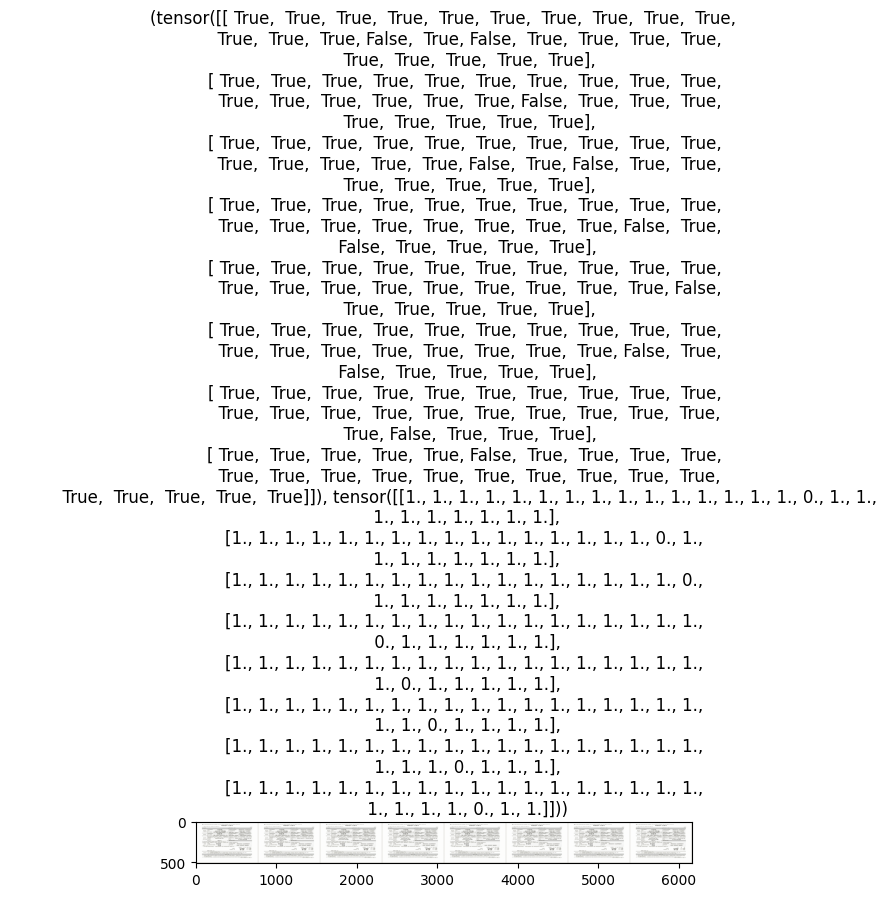

tensor([[9.9975e-01, 9.9943e-01, 9.9988e-01, 9.9931e-01, 9.9974e-01, 9.3089e-01,
         9.9872e-01, 9.9861e-01, 9.9968e-01, 9.9994e-01, 9.8238e-01, 9.9968e-01,
         1.0000e+00, 9.9978e-01, 9.9912e-01, 9.9982e-01, 9.9806e-01, 9.9427e-01,
         9.9183e-01, 9.9914e-01, 9.6455e-01, 9.9993e-01, 9.6027e-01, 3.3687e-01,
         2.2312e-02],
        [9.9961e-01, 9.9944e-01, 9.9991e-01, 9.9948e-01, 9.9982e-01, 7.1036e-01,
         9.9769e-01, 9.9587e-01, 9.9951e-01, 9.9995e-01, 9.1811e-01, 9.9938e-01,
         1.0000e+00, 9.9969e-01, 9.9907e-01, 9.9973e-01, 9.9647e-01, 9.8050e-01,
         9.8901e-01, 9.9842e-01, 9.1610e-01, 9.9989e-01, 9.7935e-01, 7.2483e-01,
         4.9180e-02],
        [9.9765e-01, 9.9980e-01, 9.9990e-01, 9.9992e-01, 9.9981e-01, 1.4037e-01,
         9.9987e-01, 5.1645e-01, 9.9925e-01, 9.9996e-01, 3.0875e-01, 9.8601e-01,
         9.9388e-01, 8.5865e-01, 9.9739e-01, 7.3666e-01, 8.9221e-01, 4.4359e-02,
         9.6652e-01, 9.9908e-01, 9.6456e-01, 9.9987e-01, 9.9007e-

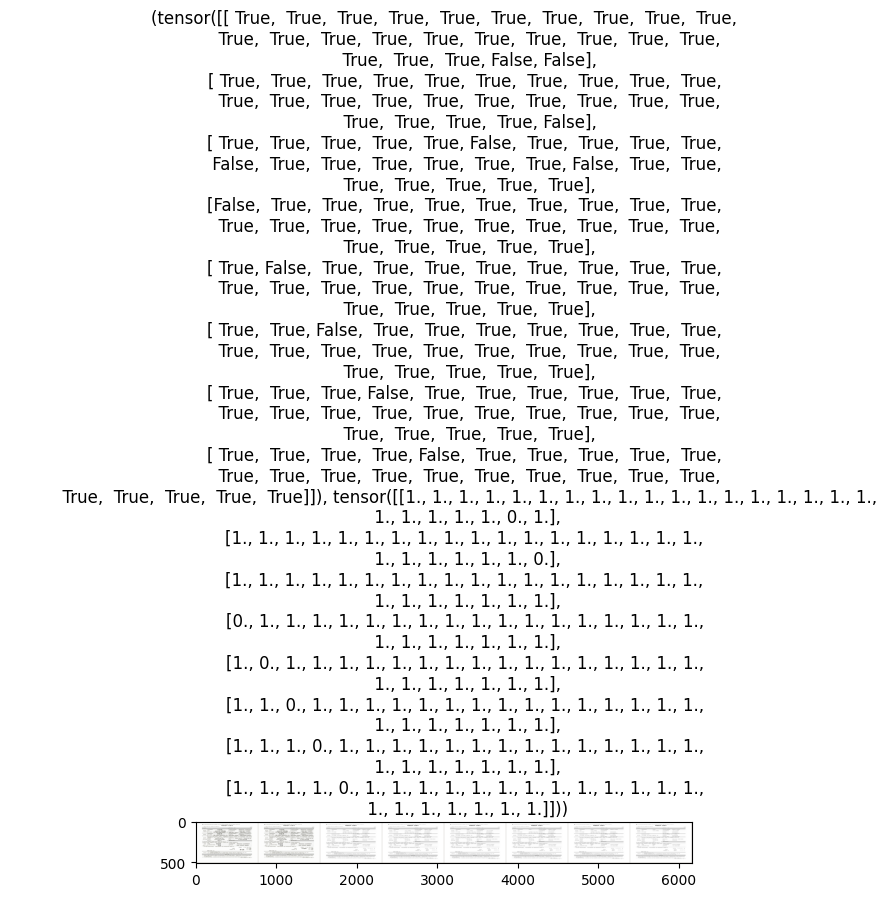

tensor([[0.9976, 0.9998, 0.9999, 0.9999, 0.9998, 0.1399, 0.9999, 0.5340, 0.9993,
         1.0000, 0.3021, 0.9853, 0.9906, 0.8520, 0.9968, 0.7221, 0.8662, 0.0469,
         0.9723, 0.9992, 0.9708, 0.9999, 0.9907, 0.9951, 0.9787],
        [0.9998, 0.9999, 0.9999, 0.0368, 0.9962, 0.9948, 0.0218, 0.9989, 0.9888,
         0.9999, 0.9993, 1.0000, 1.0000, 0.9926, 0.9996, 0.9933, 0.9998, 0.9934,
         0.9991, 0.9989, 0.9997, 0.9969, 0.9991, 0.9983, 0.9970],
        [0.9979, 0.9998, 0.9999, 0.9999, 0.9998, 0.1013, 0.9999, 0.3811, 0.9993,
         0.9999, 0.2399, 0.9858, 0.9931, 0.8975, 0.9978, 0.8492, 0.8835, 0.0754,
         0.9702, 0.9993, 0.9474, 0.9999, 0.9886, 0.9957, 0.9763],
        [0.9998, 0.9999, 0.9998, 0.9999, 0.9993, 0.8371, 0.2137, 0.9880, 0.0070,
         0.9999, 0.9694, 0.2231, 0.9998, 0.9844, 0.9997, 0.9686, 0.9998, 0.6192,
         0.9949, 0.9999, 0.9992, 0.9995, 0.9984, 0.9965, 0.9909],
        [0.9986, 0.9993, 0.9999, 0.9998, 0.9976, 0.8530, 0.9997, 0.0159, 0.9976,
       

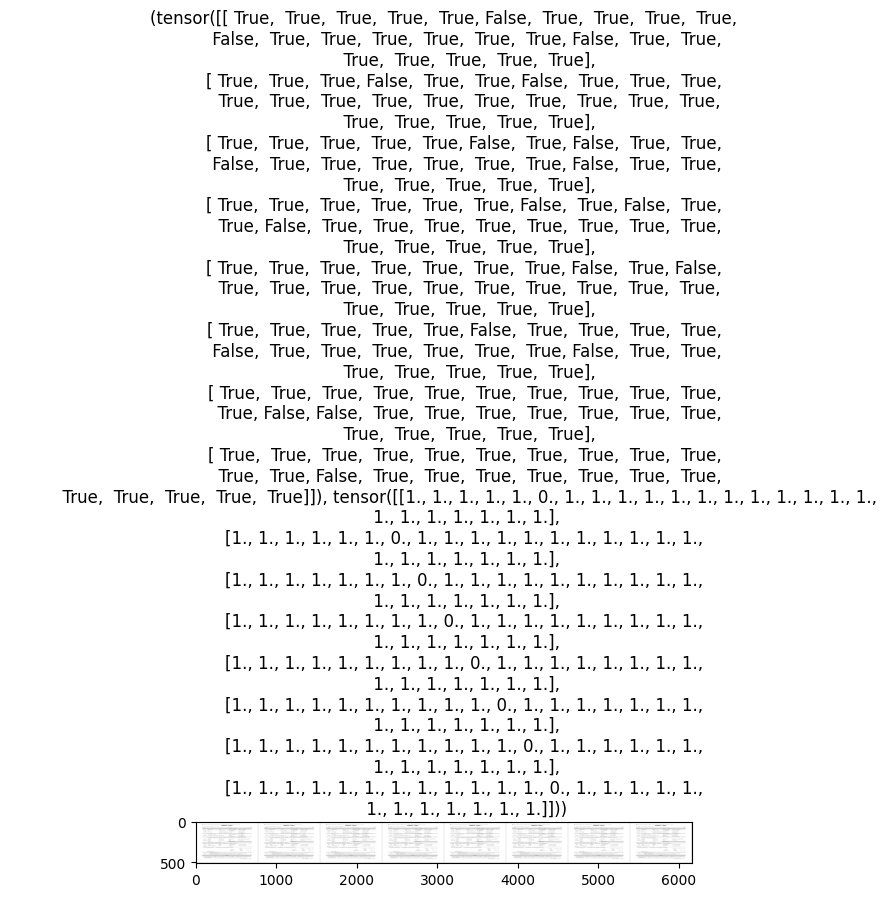

tensor([[0.9993, 0.9999, 0.9990, 0.9988, 1.0000, 0.9916, 0.9997, 0.9448, 0.9991,
         0.9981, 0.9953, 0.9999, 0.8373, 0.0196, 0.9995, 0.0434, 0.9998, 0.9723,
         0.9997, 0.9994, 0.9998, 0.9998, 0.9972, 0.9860, 0.9738],
        [1.0000, 0.9999, 0.9999, 0.9997, 0.9982, 0.9998, 0.9995, 0.9998, 0.9990,
         1.0000, 0.9999, 0.9999, 0.9626, 0.9984, 0.0140, 0.9941, 0.9901, 0.9995,
         0.9998, 0.9981, 0.9999, 0.9997, 0.9999, 0.9989, 0.9996],
        [0.9994, 0.9999, 0.9991, 0.9991, 1.0000, 0.9908, 0.9998, 0.9589, 0.9993,
         0.9995, 0.9951, 0.9998, 0.9051, 0.0265, 0.9992, 0.0301, 0.9996, 0.9358,
         0.9993, 0.9994, 0.9997, 0.9998, 0.9979, 0.9891, 0.9810],
        [1.0000, 0.9996, 1.0000, 0.9999, 0.9998, 0.9936, 1.0000, 0.9983, 0.9999,
         1.0000, 0.9963, 0.9994, 0.9707, 0.9993, 0.3164, 0.9975, 0.0398, 0.9855,
         0.9996, 0.9997, 0.9996, 0.9997, 0.9994, 0.9998, 0.9997],
        [0.9992, 0.9999, 0.9997, 0.9998, 0.9998, 0.7840, 0.9999, 0.8415, 0.9997,
       

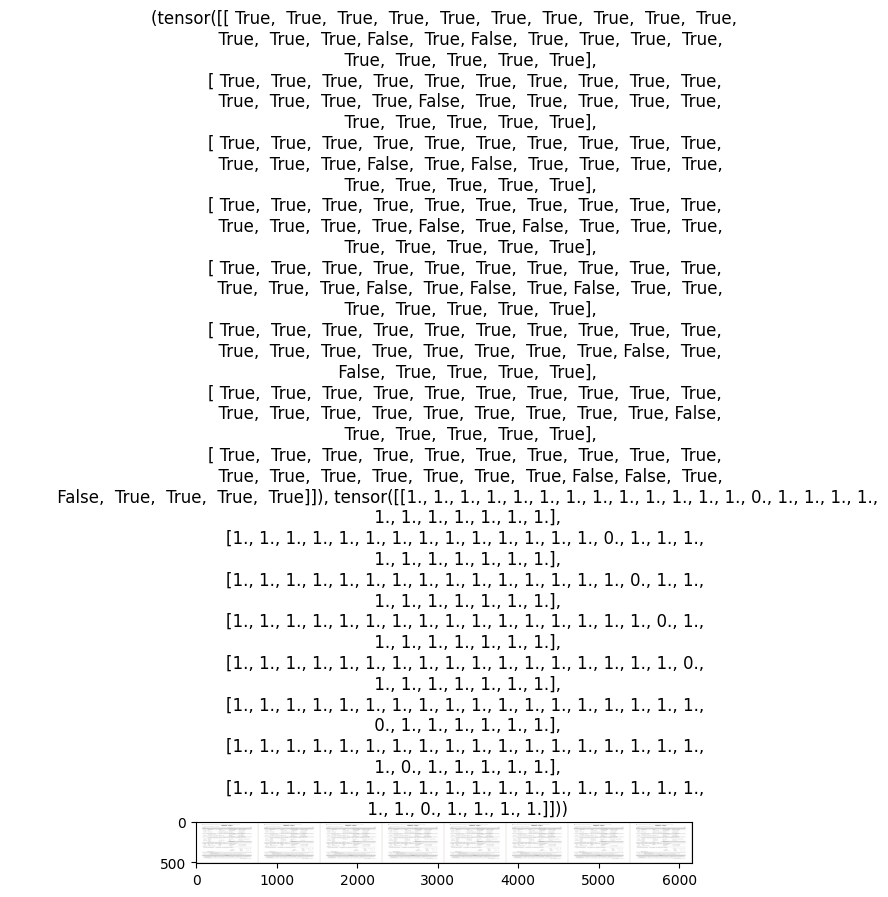

tensor([[1.0000, 1.0000, 0.9998, 0.9998, 0.9991, 0.9983, 0.9988, 0.9994, 0.9997,
         0.9999, 0.9998, 1.0000, 1.0000, 0.9971, 0.9994, 0.9945, 0.9973, 0.9949,
         0.9995, 0.9368, 0.9997, 0.0360, 0.9891, 0.9999, 1.0000],
        [0.9999, 0.9999, 0.9996, 0.9998, 0.9994, 0.9948, 0.9999, 0.9952, 0.9998,
         1.0000, 0.9970, 0.9996, 0.9981, 0.9948, 0.9963, 0.9911, 0.9883, 0.9775,
         0.9955, 1.0000, 0.9982, 0.9994, 0.0083, 0.5623, 0.5546],
        [0.9997, 0.9998, 0.9998, 0.9996, 0.9996, 0.9921, 1.0000, 0.9928, 0.9998,
         1.0000, 0.9951, 0.9993, 0.9956, 0.9907, 0.9982, 0.9842, 0.9943, 0.9372,
         0.9904, 0.9999, 0.9971, 1.0000, 0.8479, 0.0288, 0.0303],
        [0.9996, 0.9997, 0.9999, 0.9996, 0.9997, 0.9803, 1.0000, 0.9874, 0.9998,
         1.0000, 0.9878, 0.9990, 0.9950, 0.9854, 0.9984, 0.9740, 0.9918, 0.8633,
         0.9924, 0.9998, 0.9969, 1.0000, 0.9525, 0.0348, 0.0153]],
       device='cuda:0')


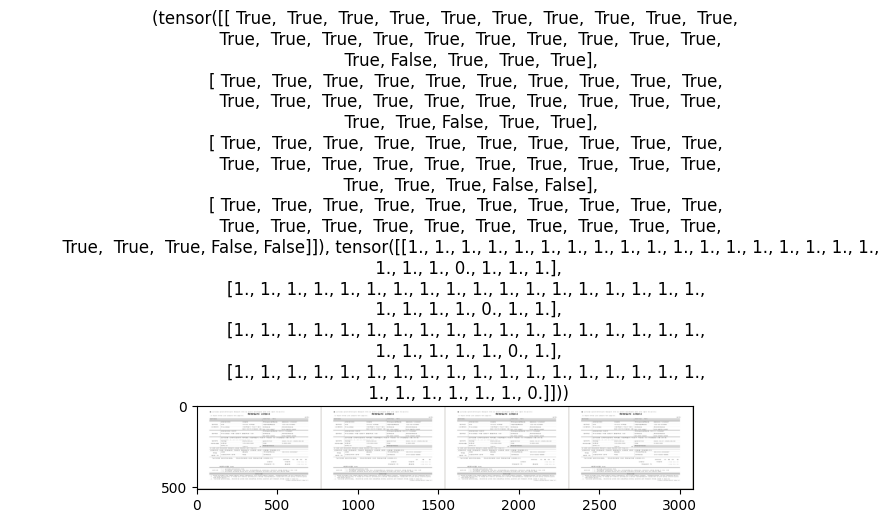

정확도 : 0.9646153846153847


In [103]:
model.eval()

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        print(probs)
        pred = probs > 0.5  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        img_grid = torchvision.utils.make_grid(img.cpu())

        imshow(img_grid, title=(pred.cpu(), labels.cpu()))

    acc = corrects / total
    print("정확도 :", acc)

In [87]:
from sklearn.metrics import f1_score
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for imgs, labels in test_dataloader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        preds = torch.sigmoid(outputs)
        print(preds)
        preds = (preds > 0.5).int()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

micro_f1 = f1_score(all_labels, all_preds, average="micro")
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

tensor([[9.9895e-01, 9.9960e-01, 9.9993e-01, 9.9993e-01, 9.9981e-01, 1.7217e-01,
         9.9341e-01, 9.7876e-01, 9.9911e-01, 9.9992e-01, 6.3261e-01, 9.9810e-01,
         1.0000e+00, 9.9906e-01, 9.9890e-01, 9.9911e-01, 9.9334e-01, 8.6768e-01,
         9.5724e-01, 9.9651e-01, 7.3330e-01, 9.9846e-01, 9.9881e-01, 9.9991e-01,
         9.9808e-01],
        [6.5444e-05, 9.9997e-01, 9.9998e-01, 9.9987e-01, 9.9980e-01, 9.9924e-01,
         9.9973e-01, 9.9909e-01, 9.9971e-01, 9.9988e-01, 9.9931e-01, 9.9982e-01,
         9.9980e-01, 9.9944e-01, 9.9965e-01, 9.9953e-01, 9.9981e-01, 9.9955e-01,
         9.9975e-01, 9.9934e-01, 9.9965e-01, 9.9974e-01, 9.9992e-01, 9.9951e-01,
         9.9947e-01],
        [9.9996e-01, 3.7278e-05, 9.9998e-01, 9.9994e-01, 9.9991e-01, 9.9955e-01,
         9.9989e-01, 9.9983e-01, 9.9992e-01, 9.9991e-01, 9.9979e-01, 9.9992e-01,
         9.9995e-01, 9.9980e-01, 9.9987e-01, 9.9984e-01, 9.9973e-01, 9.9980e-01,
         9.9983e-01, 9.9988e-01, 9.9975e-01, 9.9995e-01, 9.9992e-

In [104]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

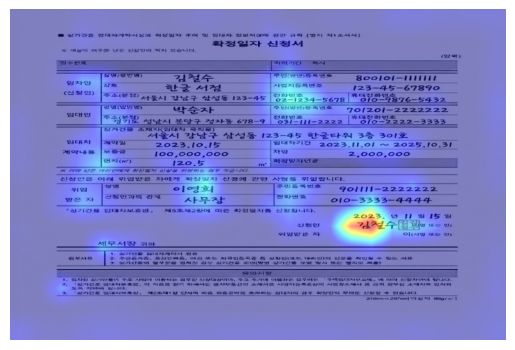

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
model.to("cuda")

img = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data3\train\001-25_위임받은_자_없음.jpg"
).convert("RGB")
input_tensor = transform_test(img).unsqueeze(0).to("cuda")

# 마지막 stage grad 활성화
for param in model.features[-1].parameters():
    param.requires_grad = True

pred = model(input_tensor)

target_class = 24

target_layers = [model.features[-1][-1]]

cam = GradCAM(model=model, target_layers=target_layers)

grad_cam = cam(
    input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)]
)[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")

In [ ]:
from torchvision import datasets, models, transforms

transform_train = transforms.Compose(
    [
        transforms.Resize((512, 768)),
        transforms.RandomRotation(2),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.ToTensor(),
        transforms.Normalize([0.9313, 0.9314, 0.9307], [0.1014, 0.1016, 0.1015]),
    ]
)


transform_test = transforms.Compose(
    [
        transforms.Resize((512, 768)),
        transforms.ToTensor(),
        transforms.Normalize([0.9313, 0.9314, 0.9307], [0.1014, 0.1016, 0.1015]),
    ]
)